# Solution: Distribution Transformations -- Diamonds Dataset

**Exercises from notebook `01_distribution_transformations.ipynb`**

Jingxu Li - 320230942071


## Exercise 1: Skewness Diagnosis

Load the seaborn diamonds dataset. Check the skewness of price, carat, and depth. Which need transformation?


price    -- skewness =   1.6184  needs transform
carat    -- skewness =   1.1166  needs transform
depth    -- skewness =  -0.0823  approximately symmetric


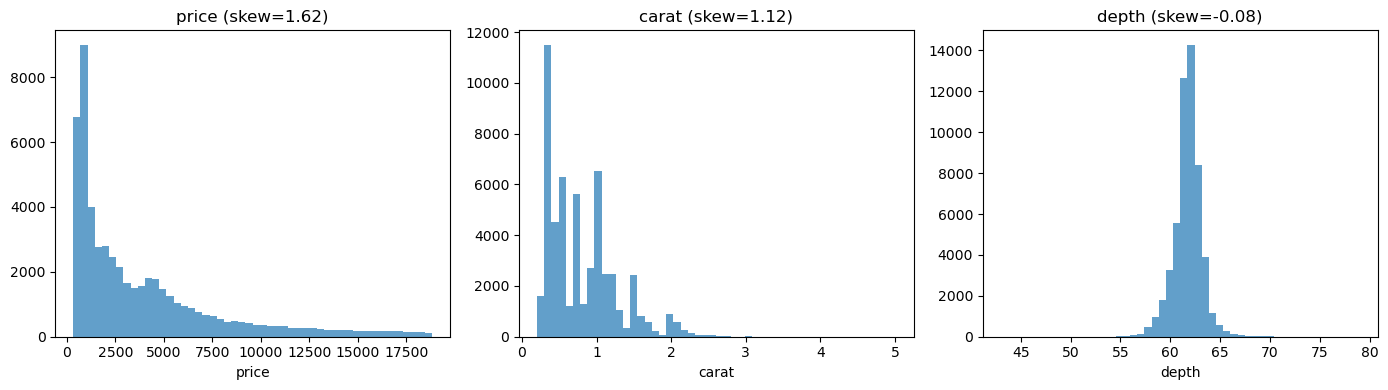

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

df = pd.read_csv('../dataset/diamonds.csv')

for col in ['price', 'carat', 'depth']:
    s = skew(df[col].dropna())
    print(f"{col:8s} -- skewness = {s:8.4f}  {'needs transform' if abs(s) > 0.5 else 'approximately symmetric'}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['price', 'carat', 'depth']):
    ax.hist(df[col], bins=50, alpha=0.7)
    ax.set_title(f'{col} (skew={skew(df[col]):.2f})')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()


## Exercise 2: Yeo-Johnson in Pipeline

Apply Yeo-Johnson to all three columns inside a Pipeline with a Ridge regressor predicting log(price). Compare R2 with and without the transformation.


No transform R2: 0.3600 +/- 0.3816
Yeo-Johnson  R2: 0.9819 +/- 0.0151
Delta: +0.6218

carat = -1.2501
depth = 1.5677
price = -0.0674


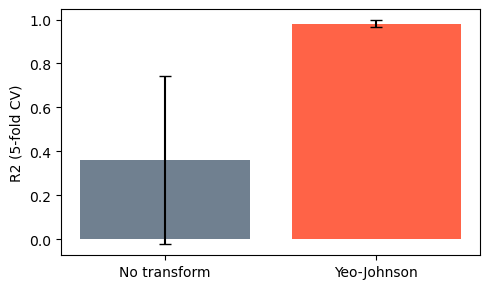

In [21]:
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

X = df[['carat', 'depth', 'price']].values
y = np.log(df['price'].values)

base = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
yj_pipe = make_pipeline(PowerTransformer(method='yeo-johnson'), StandardScaler(), Ridge(alpha=1.0))

base_scores = cross_val_score(base, X, y, cv=5, scoring='r2')
yj_scores = cross_val_score(yj_pipe, X, y, cv=5, scoring='r2')

delta = yj_scores.mean() - base_scores.mean()
print(f"No transform R2: {base_scores.mean():.4f} +/- {base_scores.std():.4f}")
print(f"Yeo-Johnson  R2: {yj_scores.mean():.4f} +/- {yj_scores.std():.4f}")
print(f"Delta: {delta:+.4f}")
print()

pt = PowerTransformer(method='yeo-johnson').fit(X)
for name, lam in zip(['carat', 'depth', 'price'], pt.lambdas_):
    print(f"{name} = {lam:.4f}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['No transform', 'Yeo-Johnson'], [base_scores.mean(), yj_scores.mean()],
       yerr=[base_scores.std(), yj_scores.std()], capsize=4, color=['slategray', 'tomato'])
ax.set_ylabel('R2 (5-fold CV)')
plt.tight_layout()
plt.show()


## Exercise 3: log1p on an Approximately Normal Feature

What happens when you apply log1p to a feature that is already approximately normal (e.g. depth in diamonds)? Plot the Q-Q plot before and after.


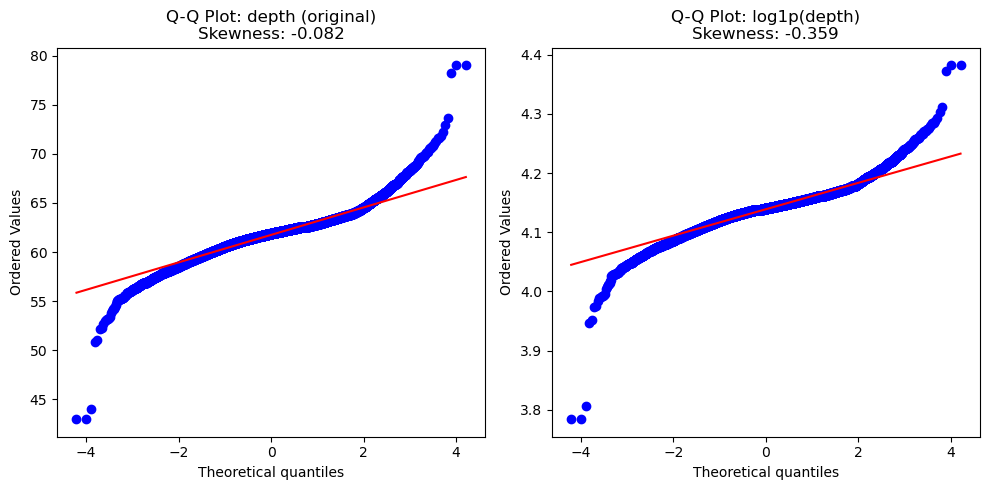

Observation: Applying log1p to an already symmetric feature
introduces left-skewness and worsens normality.
Transformation should only be applied to skewed features.


In [3]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original depth
stats.probplot(df['depth'].dropna(), dist='norm', plot=axes[0])
axes[0].set_title(f'Q-Q Plot: depth (original)\nSkewness: {skew(df["depth"].dropna()):.3f}')

# log1p depth
depth_log = np.log1p(df['depth'].dropna())
stats.probplot(depth_log, dist='norm', plot=axes[1])
axes[1].set_title(f'Q-Q Plot: log1p(depth)\nSkewness: {skew(depth_log):.3f}')

plt.tight_layout()
plt.show()

print("Observation: Applying log1p to an already symmetric feature")
print("introduces left-skewness and worsens normality.")
print("Transformation should only be applied to skewed features.")


## Exercise 4: SkewnessSelector Transformer

Implement a SkewnessSelector transformer that only applies PowerTransformer to columns whose |skewness| > 0.5 and passes other columns through unchanged.


Column   skew_in      act      skew_out
---------------------------------------------
price     +1.6184  YeoJohnson   +0.0257
carat     +1.1166  YeoJohnson   +0.1179
depth     -0.0823  passthrough   -0.0823

Mean |skew| reduction: 0.8638


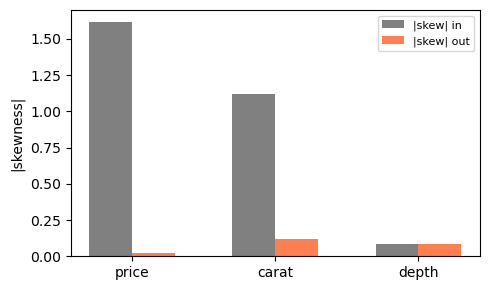

In [19]:
from sklearn.base import BaseEstimator, TransformerMixin

class SkewnessSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.5, method='yeo-johnson'):
        self.threshold = threshold
        self.method = method
        self.raw_skew_ = None
        self.fitted_ = {}
        self.label_ = {}

    def fit(self, X, y=None):
        X = np.asarray(X)
        self.raw_skew_ = np.array([sp_skew(X[:, i], nan_policy='omit') for i in range(X.shape[1])])
        for c in range(X.shape[1]):
            if abs(self.raw_skew_[c]) > self.threshold:
                m = PowerTransformer(method=self.method)
                m.fit(X[:, [c]])
                self.fitted_[c] = m
                self.label_[c] = 'yj'
            else:
                self.label_[c] = 'id'
        return self

    def transform(self, X, y=None):
        X = np.asarray(X, dtype=float)
        Z = X.copy()
        for c, m in self.fitted_.items():
            Z[:, c] = m.transform(X[:, [c]]).ravel()
        return Z

cols = ['price', 'carat', 'depth']
raw = df[cols].values
obj = SkewnessSelector(threshold=0.5)
adj = obj.fit_transform(raw)

row = '{:<8} {:>+8.4f}  {:<5}  {:>+8.4f}'
print('Column   skew_in      act      skew_out')
print('-' * 45)
for j, nam in enumerate(cols):
    sk_out = sp_skew(adj[:, j], nan_policy='omit')
    act = 'YeoJohnson' if obj.label_[j] == 'yj' else 'passthrough'
    print(row.format(nam, obj.raw_skew_[j], act, sk_out))

sk_after = np.array([abs(sp_skew(adj[:, j], nan_policy='omit')) for j in range(3)])
drops = abs(obj.raw_skew_) - sk_after
print(f'\nMean |skew| reduction: {drops.mean():.4f}')

fig, ax = plt.subplots(figsize=(5, 3))
x = np.arange(3)
w = 0.3
ax.bar(x - w/2, abs(obj.raw_skew_), w, label='|skew| in', color='gray')
ax.bar(x + w/2, sk_after, w, label='|skew| out', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(cols)
ax.set_ylabel('|skewness|')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
